In [1]:
from PIL import Image
import cv2
import matplotlib.pyplot as plt
import numpy as np
import sys
from skimage import io
from skimage.color import rgb2gray
from skimage.filters import gaussian
from skimage.segmentation import active_contour
from scipy.optimize import curve_fit

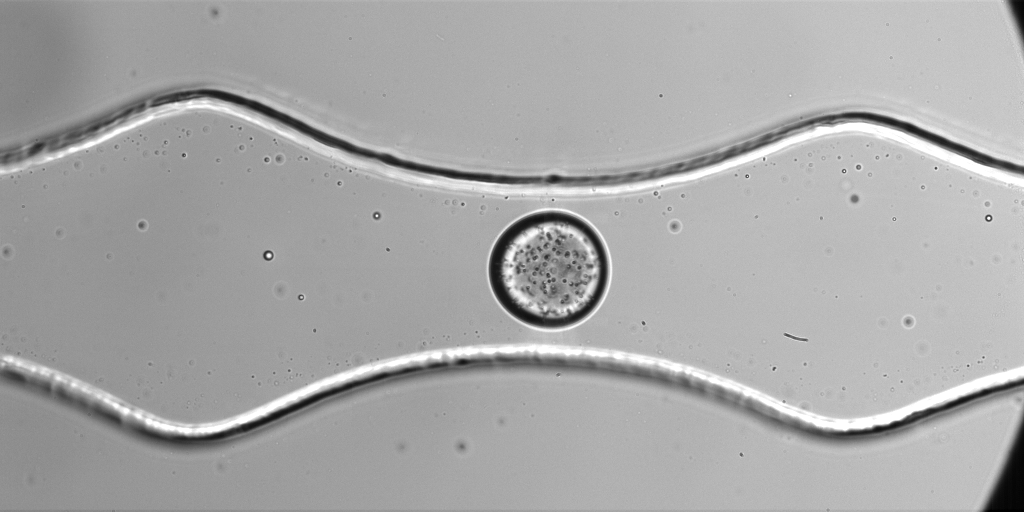

In [2]:
#HELE-SHAW droplets
image_path = '/Volumes/Elements/Rheoflu/Luca/Constrict_5/Constrict_5000460.tif'
#image_path = '/Volumes/Elements/Rheoflu/Luca/Constrict_5/Constrict_5000600.tif'
#image_path = '/Volumes/Elements/Rheoflu/Luca/Constrict_5/Constrict_5000760.tif'
#CELLS
#image_path = '/Volumes/Elements/Rheoflu/Luca/20250918_cellTHP1Paolo_test1/20250918_CellTHP1_100w_60h_08muls/0_film/cell0/cell0000015.tif'
#COACERVATES
#image_path = '/Volumes/Elements/Rheoflu/Luca/20251023_Frasatest_coacervates/1_test_CTPK240_05mM_tcGG_h60_d100/channel2_constriction5/constriction5/constriction5005635.tif'


image_path_firstframe = '/Volumes/Elements/Rheoflu/Luca/Constrict_5/Constrict_5000001.tif'
#image_path_firstframe = '/Volumes/Elements/Rheoflu/Luca/20250918_cellTHP1Paolo_test1/20250918_CellTHP1_100w_60h_08muls/0_film/cell0/cell0000020.tif'
#image_path_firstframe = '/Volumes/Elements/Rheoflu/Luca/20251023_Frasatest_coacervates/1_test_CTPK240_05mM_tcGG_h60_d100/channel2_constriction5/constriction5/constriction5005621.tif'

if cv2.imread(image_path) is None:
    print("Immagine non trovata. Hai collegato l'SSD?")
    sys.exit()

img = Image.open(image_path)
img1 = Image.open(image_path_firstframe)
img

# 1) **Template Matching**

Using cv2.matchTemplate(img, template, cv2.TM_CCOEFF_NORMED) each pixel of img receives a vote of the similarity with the template. The top left corner of the templete is taken as reference. 

Oggetto trovato con affidabilità: 0.82


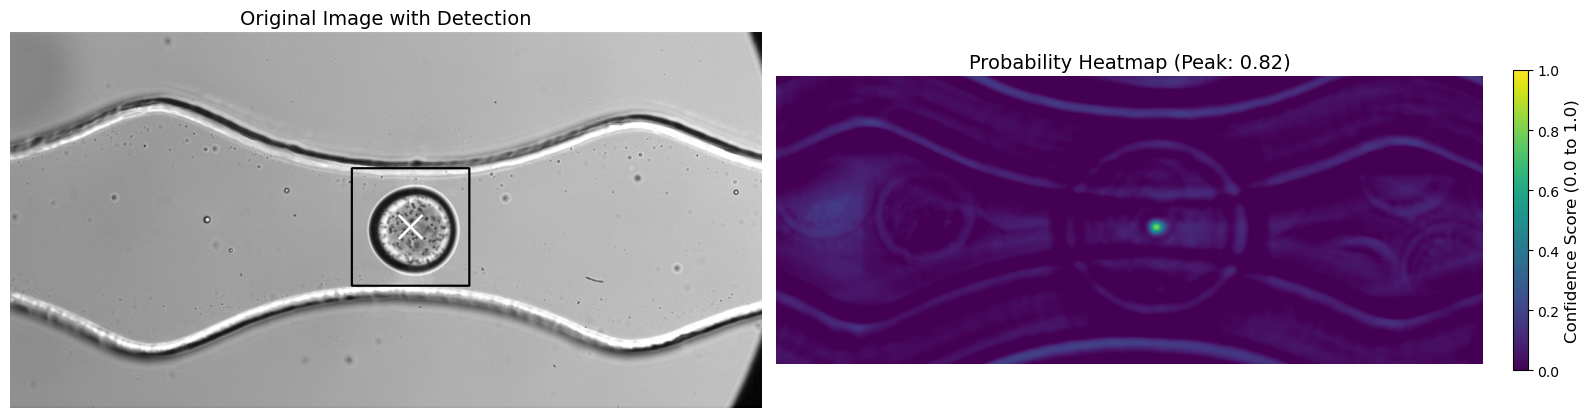

In [3]:
img = cv2.imread(image_path) #converto in array
img1 = cv2.imread(image_path_firstframe)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray_img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)

y_center = 260 # --- HELE-SHAW ---
x_center = 100
radius = 80
#y_center = 194 # --- CELL ---
#x_center = 133
#radius = 20
#y_center = 53 # --- COACERVATE---
#x_center = 233
#radius = 10
template = gray_img1[y_center - radius : y_center + radius, x_center - radius : x_center + radius] #hele-shaw
h, w = template.shape # dimensioni del template

result = cv2.matchTemplate(gray, template, cv2.TM_CCOEFF_NORMED)
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result) #trova valori e coordinate di min e max

soglia = 0.60
if max_val >= soglia:
    top_left = max_loc      
    bottom_right = (top_left[0] + w, top_left[1] + h)
    
    ROI = gray[top_left[1]:bottom_right[1], top_left[0]:bottom_right[0]].copy() #togliere.copy se si vuole risparmiare memoria

    cv2.rectangle(gray, top_left, bottom_right, (0, 255, 0), 2) 
    print(f"Oggetto trovato con affidabilità: {max_val:.2f}")

    x_center = top_left[0] + (w//2) 
    y_center = top_left[1] + (h//2)
    cv2.drawMarker(gray, (x_center, y_center), (255, 0, 0), cv2.MARKER_TILTED_CROSS, 30, 3) 

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    ax1.imshow(gray, cmap='gray')
    ax1.set_title("Original Image with Detection", fontsize=14)
    ax1.axis('off') 
    
    heatmap = ax2.imshow(result, cmap='viridis', vmin=0, vmax=1)
    ax2.set_title(f"Probability Heatmap (Peak: {max_val:.2f})", fontsize=14)
    ax2.axis('off')
    
    cbar = fig.colorbar(heatmap, ax=ax2, fraction=0.02, pad=0.04)
    cbar.set_label('Confidence Score (0.0 to 1.0)', fontsize=12)
    
    plt.tight_layout()
    plt.show()

else:
    print("Oggetto non trovato nel frame.")

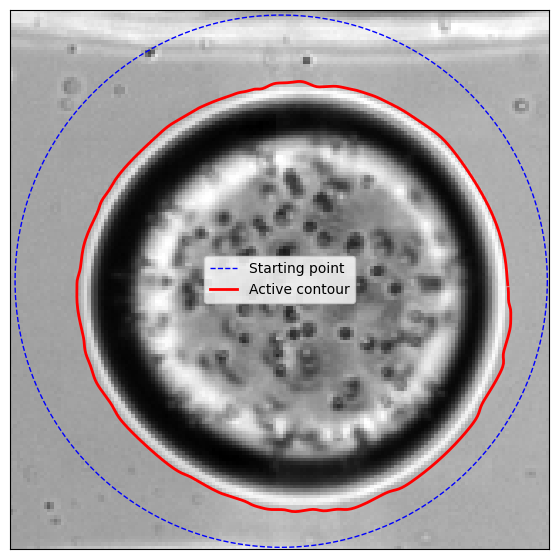

In [4]:
h_roi, w_roi = ROI.shape
radius = min(h_roi, w_roi) / 2 - 1

s = np.linspace(0, 2 * np.pi, 400) #crea il cerchio iniziale
y = h_roi//2 + radius * np.sin(s)
x = w_roi//2 + radius * np.cos(s)

ROI_blur= gaussian(ROI, sigma=1.95)  #cells=1.5,coac=1.95
#ROI_blur= cv2.GaussianBlur(gray, (0.1, 0.1), 0)
init = np.array([y, x]).T 
contour = active_contour(ROI_blur, init, alpha=1.5, beta=10.0, w_edge=5.0, w_line=0.0, boundary_condition='periodic')


fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(ROI, cmap=plt.cm.gray)
ax.plot(init[:, 1], init[:, 0], '--b', lw=1, label="Starting point")
ax.plot(contour[:, 1], contour[:, 0], '-r', lw=2, label="Active contour")
ax.set_xticks([]), ax.set_yticks([]) # Nasconde i numeri sugli assi
ax.legend()
plt.show()

Average radius a0 = 63.61
Cosines parameters (a1..a4) = [ 1.36  0.46 -0.77  0.04]


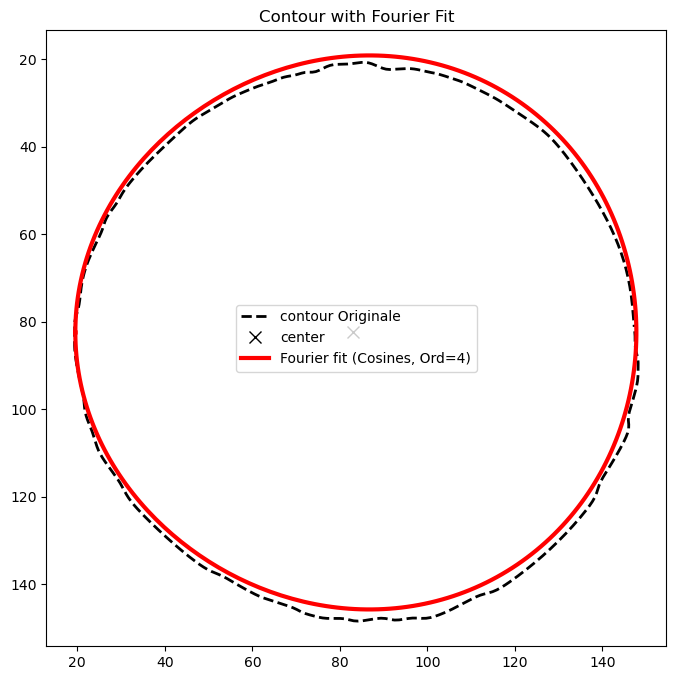

In [5]:
y_contour = contour[:, 0] #invertiamo le colonne di contour
x_contour = contour[:, 1]

center_x = np.mean(x_contour) # Troviamo il centro di massa del contour e le fissiamo come origine
center_y = np.mean(y_contour)
x_centrato = x_contour - center_x
y_centrato = y_contour - center_y
theta_contour = np.arctan2(y_centrato, x_centrato) # Cartesian > Polar
radius_contour = np.sqrt(x_centrato**2 + y_centrato**2)

# --- 3. FUNZIONE DI FITTING (Ordine 4, Solo Coseni) ---
def fourier_cos(theta, a0, a1, a2, a3, a4):
    return (a0 + 
            a1 * np.cos(1 * theta) + 
            a2 * np.cos(2 * theta) + 
            a3 * np.cos(3 * theta) + 
            a4 * np.cos(4 * theta))

# --- 4. CALCOLO DEI PARAMETRI ---
fit_parameters, _ = curve_fit(fourier_cos, theta_contour, radius_contour) #fit con minimi quadrati. curve_fit(funzione, input fissati, input da fittaare)
print(f"Average radius a0 = {fit_parameters[0]:.2f}")
print(f"Cosines parameters (a1..a4) = {np.round(fit_parameters[1:], 2)}")

theta_fit = np.linspace(-np.pi, np.pi, 300)            #disegno una curva con i parametri del fit
radius_fit = fourier_cos(theta_fit, *fit_parameters) 

x_fit = center_x + radius_fit * np.cos(theta_fit)      # Polar > Cartesian
y_fit = center_y + radius_fit * np.sin(theta_fit)
fig, ax = plt.subplots(figsize=(8, 8))

# contour reale trovato dall'active contour
ax.plot(x_contour, y_contour, '--k', lw=2, label='contour Originale')

# center calcolato
ax.plot(center_x, center_y, 'kx', markersize=8, label='center')

# Forma ideale calcolata col fitting dei coseni
ax.plot(x_fit, y_fit, '-r', lw=3, label='Fourier fit (Cosines, Ord=4)')

ax.set_title("Contour with Fourier Fit")
ax.axis('equal') 
ax.invert_yaxis() # L'asse Y scende verso il basso nelle immagini!
ax.legend()

plt.show()

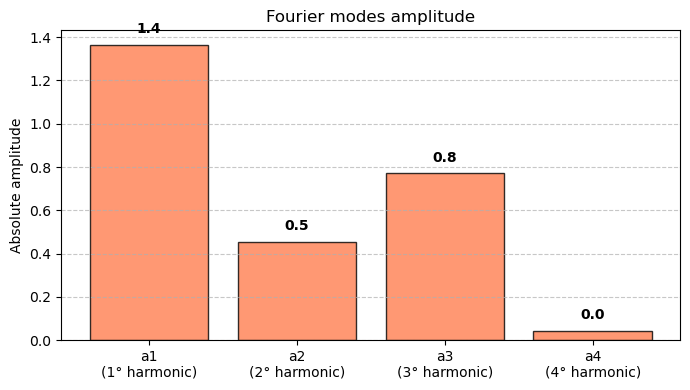

In [6]:
# Prendiamo i moduli (valori assoluti) ma SALTIAMO il primo elemento (a0) usando [1:]
harmonic_modules = np.abs(fit_parameters[1:])

# Creiamo le labels solo per le armoniche
labels = ['a1\n(1° harmonic)', 'a2\n(2° harmonic)', 'a3\n(3° harmonic)', 'a4\n(4° harmonic)']

# Creiamo il grafico (ho cambiato colore per distinguerlo dal precedente!)
plt.figure(figsize=(7, 4))
plt.bar(labels, harmonic_modules, color='coral', edgecolor='black', alpha=0.8)

# Aggiungiamo i valori esatti sopra ogni colonna
for i, valore in enumerate(harmonic_modules):
    plt.text(i, valore + (max(harmonic_modules)*0.03), f"{valore:.1f}", 
             ha='center', va='bottom', fontweight='bold')

# Rifiniture
plt.title("Fourier modes amplitude")
plt.ylabel("Absolute amplitude")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [7]:
#PER VIDEO

#cap = cv2.VideoCapture('percorso/cartella/frame_%04d.tif') # '%04d' indica che il numero nel nome del file ha 4 cifre (0001, 0002...)
#
#frames = []
#while True:
#    ret, frame = cap.read()
#    if not ret:
#        break 
#        
#    frames.append(frame)
#
#cap.release()